In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

In [3]:
metafile = pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/PEC_donor_LIMS_082625.csv', header=0, sep=',')
qcfile = pd.read_csv('./data/metadata_DNA_QC.tsv.gz',index_col = [0],compression='gzip', header=0, sep='\t')
rnaqc=pd.read_csv('./data/metadata_RNA_QC.tsv.gz',sep='\t',index_col=0)

## PCA Plot

In [ ]:
genebody_mCG=pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/regionMethylation/intragenic_masked_mCG_all.tsv.gz',sep='\t',index_col=0)
genebody_mCG=genebody_mCG.loc[qcfile[(qcfile['DNA_passQC']=='True')].index]
genebody_mCH=pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/regionMethylation/intragenic_masked_mCH_all.tsv.gz',sep='\t',index_col=0)
genebody_mCH=genebody_mCH.loc[qcfile[(qcfile['DNA_passQC']=='True')].index]
rnaexp=pd.read_csv('./data/RNA_expression_log2CPM+1.tsv.gz',sep='\t',index_col=0)
rnaexp=rnaexp[rnaqc[rnaqc['RNA_passQC']].index]

In [ ]:
gene_meta=pd.read_csv('./data/gencode.v37.annotation.intragenic.bed.gz',
                      names=['chr','start','end','gene_id','starnd','tmp','gene_name','fn'],
                      index_col='gene_id', sep='\t')
gene_meta['len']=gene_meta['end']-gene_meta['start']    

In [5]:
sex_palette={'Female':'#F16090','Male':'#61A3D7'}
celltype_palette={'GLU':'#4FAF48','GABA':'#397FBA'}
period_order=['Infancy', 'Early_Childhood', 'Late_Childhood', 'Adolescence', 'Adulthood','Late_Adulthood']

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

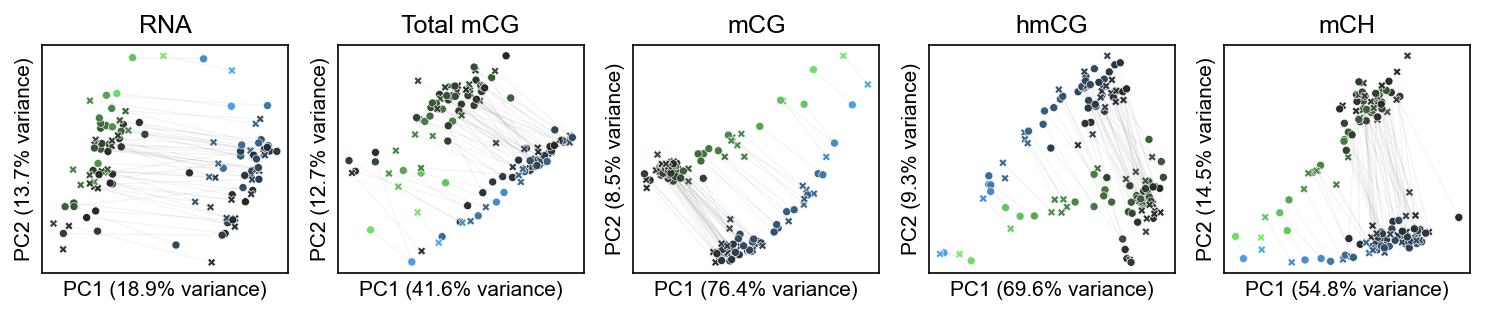

In [7]:
glu_palette = sns.dark_palette('#75eb6c', as_cmap=True, reverse=True)
gaba_palette = sns.dark_palette('#4ea7f2', as_cmap=True, reverse=True)

fig, axs = plt.subplots(1, 5, figsize=(10, 2.2), dpi=150)

for i in range(5):
    if i == 0:
        df = rnaexp.copy()
        df = df.loc[list(set(df.index).intersection(set(gene_meta[(gene_meta['fn'].isin(['protein_coding'])) & (gene_meta['len'] > 1000) & ~(gene_meta['chr'].str.contains('[XYM]'))].index)))].dropna().T
        df_meta = df.join(rnaqc[['age', 'celltype', 'sex']])[['age', 'celltype', 'sex']]
        title = 'RNA'
    elif i == 1:
        df = genebody_mCG[genebody_mCG.index.str.contains(f'_BS')].T
        df = df.loc[list(set(df.index).intersection(set(gene_meta[(gene_meta['fn'].isin(['protein_coding'])) & (gene_meta['len'] > 1000) & ~(gene_meta['chr'].str.contains('[XYM]'))].index)))].dropna().T
        df_meta = df.join(qcfile[['age', 'celltype', 'sex', 'DNA_passQC']])[['age', 'celltype', 'sex', 'DNA_passQC']]
        title = 'Total mCG'
    elif i == 2:
        df = genebody_mCG[genebody_mCG.index.str.contains(f'_OXBS')].T
        df = df.loc[list(set(df.index).intersection(set(gene_meta[(gene_meta['fn'].isin(['protein_coding'])) & (gene_meta['len'] > 1000) & ~(gene_meta['chr'].str.contains('[XYM]'))].index)))].dropna().T
        df_meta = df.join(qcfile[['age', 'celltype', 'sex', 'DNA_passQC']])[['age', 'celltype', 'sex', 'DNA_passQC']]
        title = 'mCG'
    elif i == 3:
        bs=genebody_mCG[genebody_mCG.index.str.contains(f'_BS')].T
        ox=genebody_mCG[genebody_mCG.index.str.contains(f'_OXBS')].T
        bs.columns = bs.columns.str.replace('_BS','')
        ox.columns = ox.columns.str.replace('_OXBS','')
        df = bs-ox
        df[df<0]=0
        df.columns = df.columns+'_BS'
        df = df.loc[list(set(df.index).intersection(set(gene_meta[(gene_meta['fn'].isin(['protein_coding'])) & (gene_meta['len'] > 1000) & ~(gene_meta['chr'].str.contains('[XYM]'))].index)))].dropna().T
        df_meta = df.join(qcfile[['age', 'celltype', 'sex', 'DNA_passQC']])[['age', 'celltype', 'sex', 'DNA_passQC']]
        title = 'hmCG'
    else:
        df = genebody_mCH[genebody_mCH.index.str.contains(f'_OXBS')].T
        df = df.loc[list(set(df.index).intersection(set(gene_meta[(gene_meta['fn'].isin(['protein_coding'])) & (gene_meta['len'] > 1000) & ~(gene_meta['chr'].str.contains('[XYM]'))].index)))].dropna().T
        df_meta = df.join(qcfile[['age', 'celltype', 'sex', 'DNA_passQC']])[['age', 'celltype', 'sex', 'DNA_passQC']]
        title = 'mCH'
    
    # Standardize the data
    scaler = StandardScaler()
    df = scaler.fit_transform(df)
    pca = PCA(n_components=2)
    projected = pca.fit_transform(df)

    df_meta['PC1'] = projected[:, 0]
    df_meta['PC2'] = projected[:, 1]
    df_meta['donor'] = df_meta.index.str.split('_G').str[0]
    df_meta['logage'] = np.log10(df_meta['age'])
    
    ax = axs[i]
    for celltype, palette in [('GLU', glu_palette), ('GABA', gaba_palette)]:
        if i == 0:
            points = sns.scatterplot(
                data=df_meta[df_meta['celltype'] == celltype],
                x='PC1', y='PC2', 
                hue='logage', style='sex', markers={'Male': 'o', 'Female': 'X'},
                palette=palette, s=15, edgecolor='w', linewidth=0.3, ax=ax
            )
        else:
            sns.scatterplot(
                data=df_meta[(df_meta['celltype'] == celltype) & (df_meta['DNA_passQC'] == 'True')],
                x='PC1', y='PC2', 
                hue='logage', style='sex', markers={'Male': 'o', 'Female': 'X'},
                palette=palette, s=15, edgecolor='w', linewidth=0.3, ax=ax
            )
            sns.scatterplot(
                data=df_meta[(df_meta['celltype'] == celltype) & (df_meta['DNA_passQC'] == 'SCZ')],
                x='PC1', y='PC2', 
                style='sex', markers={'Male': 'o', 'Female': 'X'},
                s=15, edgecolor=celltype_palette[celltype], linewidth=.5, ax=ax, facecolor='none'
            )
    
    # Add lines linking celltypes from the same donors
    for donor, group in df_meta.groupby('donor'):
        if len(group) > 1:
            ax.plot(group['PC1'], group['PC2'], color='gray', linewidth=0.5, alpha=0.1)
    
    ax.set_xlabel(f'PC1 ({100 * pca.explained_variance_ratio_[0]:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({100 * pca.explained_variance_ratio_[1]:.1f}% variance)')
    ax.legend().remove()
    ax.set_xticks([]) 
    ax.set_yticks([]) 
    ax.set_title(title)

plt.tight_layout()

## Read 10kb files

In [12]:
binc = pd.read_csv('/cndd/hex002/PsychEncode/methylation/local_methylation_backgroud/10kb_methylation_CGCH_chr1_22X_NCRcorrected.tsv.gz',index_col=[0,1,2],header=[0, 1, 2, 3, 4, 5],sep = '\t')
binc.head()

subject                 4414                                          \
sex                   Female                                           
age                      0.1                                           
celltype                 GLU                                    GABA   
mctype                    BS      OXBS        BS      OXBS        BS   
ctxt                     mCG       mCG       mCH       mCH       mCG   
chr  start  end                                                        
chr1 790000 800000  0.869847  0.741499 -0.000494 -0.001806  0.947206   
     800000 810000  0.927350  0.717844  0.001761  0.001959  0.891348   
     810000 820000  0.758027  0.542781  0.000610  0.011050  0.719832   
     820000 830000  0.543049  0.324005 -0.002216 -0.003158  0.449865   
     830000 840000  0.951204  0.802650 -0.005589  0.004274  0.944305   

subject                                               4411            ...  \
sex                                                   Male            ...   
age                                                   0.15            ...   
celltype                                               GLU            ...   
mctype                  OXBS        BS      OXBS        BS      OXBS  ...   
ctxt                     mCG       mCH       mCH       mCG       mCG  ...   
chr  start  end                                                       ...   
chr1 790000 800000  0.783843  0.007497 -0.004695  0.923603  0.710533  ...   
     800000 810000  0.770546 -0.001070 -0.003737  0.928774  0.700902  ...   
     810000 820000  0.522135 -0.000365 -0.000679  0.778594  0.518656  ...   
     820000 830000  0.361536 -0.003237 -0.000973  0.403886  0.323968  ...   
     830000 840000  0.857266 -0.003672  0.001029  0.957618  0.758198  ...   

subject            HCTYPA008                                          \
sex                     Male                                           
age                    75.53                                           
celltype                 GLU                GABA                       
mctype                    BS      OXBS        BS      OXBS        BS   
ctxt                     mCH       mCH       mCG       mCG       mCH   
chr  start  end                                                        
chr1 790000 800000  0.028069  0.005934  0.993607  0.527495  0.026346   
     800000 810000  0.020503  0.015703  0.956409  0.531749  0.027215   
     810000 820000  0.018337  0.005144  0.880948  0.361904  0.024362   
     820000 830000  0.003269  0.002295  0.485237  0.250677  0.004938   
     830000 840000  0.025535  0.012876  1.000103  0.591091  0.024000   

subject                           5744                                
sex                               Male                                
age                               77.0                                
celltype                           GLU                                
mctype                  OXBS        BS      OXBS        BS      OXBS  
ctxt                     mCH       mCG       mCG       mCH       mCH  
chr  start  end                                                       
chr1 790000 800000  0.020456  0.980245  0.427371  0.029313  0.009298  
     800000 810000  0.019404  0.946011  0.443331  0.027980  0.014922  
     810000 820000  0.010581  0.846513  0.302184  0.026740  0.018090  
     820000 830000  0.003596  0.602064  0.265881  0.011095  0.009910  
     830000 840000  0.016299  0.985035  0.498391  0.024194  0.019188  

[5 rows x 620 columns]

## Genome-wide level, across all samples

In [13]:
from pathlib import Path
from matplotlib.lines import Line2D

figure1_output_dir = Path('Figure1_outputs')
figure1_output_dir.mkdir(parents=True, exist_ok=True)

autosomes = [f'chr{i}' for i in range(1, 23)]
short_read_means = binc.loc[binc.index.get_level_values(0).isin(autosomes)].mean(axis=0).rename('mean').reset_index()
short_read_means.columns = ['subject', 'sex', 'age', 'celltype', 'assay', 'ctxt', 'mean']
print(f'Short-read autosomal samples: {short_read_means.subject.nunique()}')


Short-read autosomal samples: 83


In [14]:
nanopore_cache_path = Path('data/Figure1_nanopore_genome_wide.tsv.gz')
genome_wide_methylation_df = pd.read_csv(nanopore_cache_path, sep='\t', dtype={'sample': str})
print(f'Nanopore sample/celltype profiles: {len(genome_wide_methylation_df)}')
print(genome_wide_methylation_df.groupby('celltype')['sample'].nunique().rename('n_samples'))


Nanopore sample/celltype profiles: 15
celltype
GABA    7
Glu     8
Name: n_samples, dtype: int64


In [16]:
short_read_wide

,subject,sex,age,celltype,BS_mCG,BS_mCH,OXBS_mCG,OXBS_mCH
0,003,Male,33.00,GABA,0.943642,0.054059,0.622051,0.048261
1,003,Male,33.00,GLU,0.910496,0.047076,0.525611,0.038343
2,012,Male,53.00,GABA,0.945335,0.052287,0.615561,0.045681
3,012,Male,53.00,GLU,0.915485,0.047956,0.511445,0.038246
4,061,Male,43.00,GABA,0.948657,0.052572,0.620954,0.047014
...,...,...,...,...,...,...,...,...
150,HCTYPA008,Male,75.53,GLU,0.905476,0.044880,0.511201,0.032831
151,HCTZZHA019,Female,65.00,GABA,0.925027,0.041685,0.587915,0.032868
152,HCTZZHA019,Female,65.00,GLU,0.900474,0.039966,0.503772,0.027579
153,HCTZZNA014,Female,39.19,GABA,0.923720,0.050177,0.603877,0.043279


In [17]:
short_read_wide = short_read_means.pivot_table(
    index=['subject', 'sex', 'age', 'celltype'], columns=['assay', 'ctxt'], values='mean', aggfunc='mean'
)
short_read_wide.columns = [f'{assay}_{ctxt}' for assay, ctxt in short_read_wide.columns]
short_read_wide = short_read_wide.reset_index()
short_read_wide['age'] = short_read_wide['age'].astype(float)
short_read_wide['celltype'] = short_read_wide['celltype'].str.upper()

short_read_plot_df = short_read_wide.assign(
    tmCG=short_read_wide['BS_mCG'], mCG=short_read_wide['OXBS_mCG'],
    hmCG=(short_read_wide['BS_mCG'] - short_read_wide['OXBS_mCG']).clip(lower=0),
    CH=short_read_wide['BS_mCH'], source='BS/OXBS'
)[['subject', 'sex', 'age', 'celltype', 'source', 'tmCG', 'mCG', 'hmCG', 'CH']]

long_read_plot_df = genome_wide_methylation_df.assign(
    subject=genome_wide_methylation_df['sample'], sex=np.nan,
    celltype=genome_wide_methylation_df['celltype'].str.upper(),
    tmCG=genome_wide_methylation_df['mCG'] + genome_wide_methylation_df['hmCG'],
    CH=genome_wide_methylation_df['mCH'] + genome_wide_methylation_df['hmCH'],
    source='LR nanopore'
)[['subject', 'sex', 'age', 'celltype', 'source', 'tmCG', 'mCG', 'hmCG', 'CH']]

disorder_by_subject = metafile.assign(**{'Sample ID': metafile['Sample ID'].astype(str).str.strip()}).set_index('Sample ID')['DISORDER']
short_read_plot_df['SCZ'] = np.where(short_read_plot_df['subject'].astype(str).str.strip().map(disorder_by_subject).eq('S'), 'S', 'C')
long_read_plot_df['SCZ'] = 'C'
combined_plot_df = pd.concat([short_read_plot_df, long_read_plot_df], ignore_index=True)
plot_df = combined_plot_df.melt(
    id_vars=['subject', 'sex', 'age', 'celltype', 'source', 'SCZ'],
    value_vars=['tmCG', 'mCG', 'hmCG', 'CH'], var_name='metric', value_name='level'
).dropna(subset=['age', 'level'])

print(combined_plot_df.groupby(['source', 'celltype'])['subject'].nunique().rename('n_samples'))


source       celltype
BS/OXBS      GABA        75
             GLU         80
LR nanopore  GABA         7
             GLU          8
Name: n_samples, dtype: int64


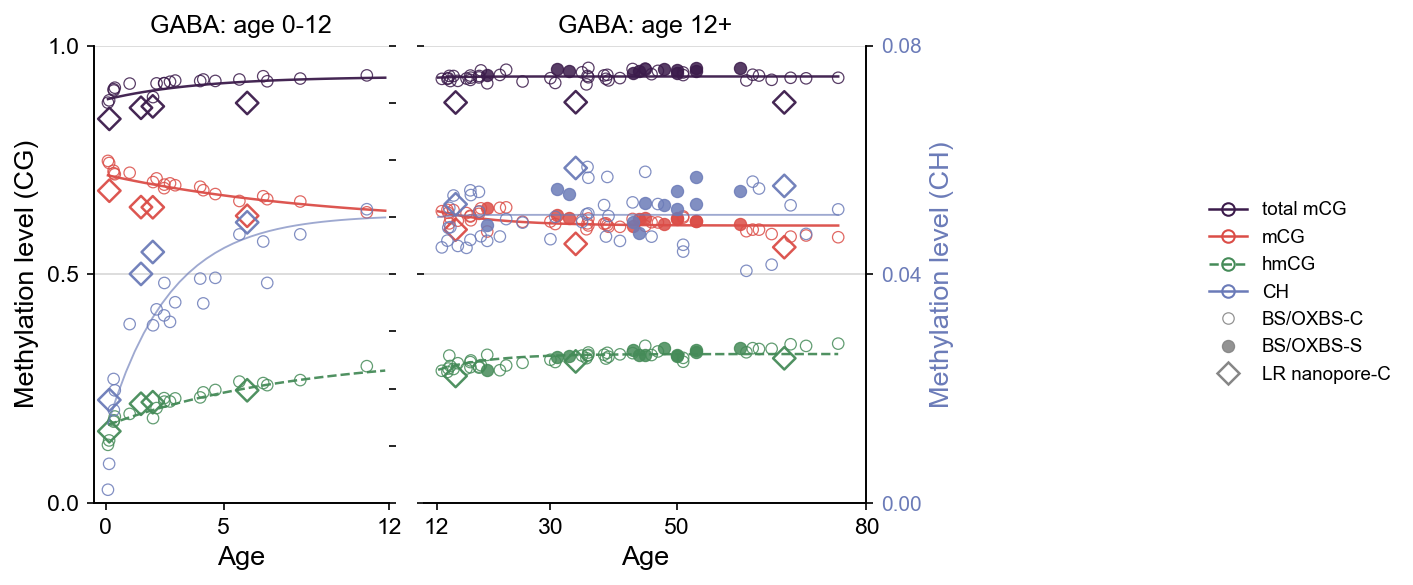

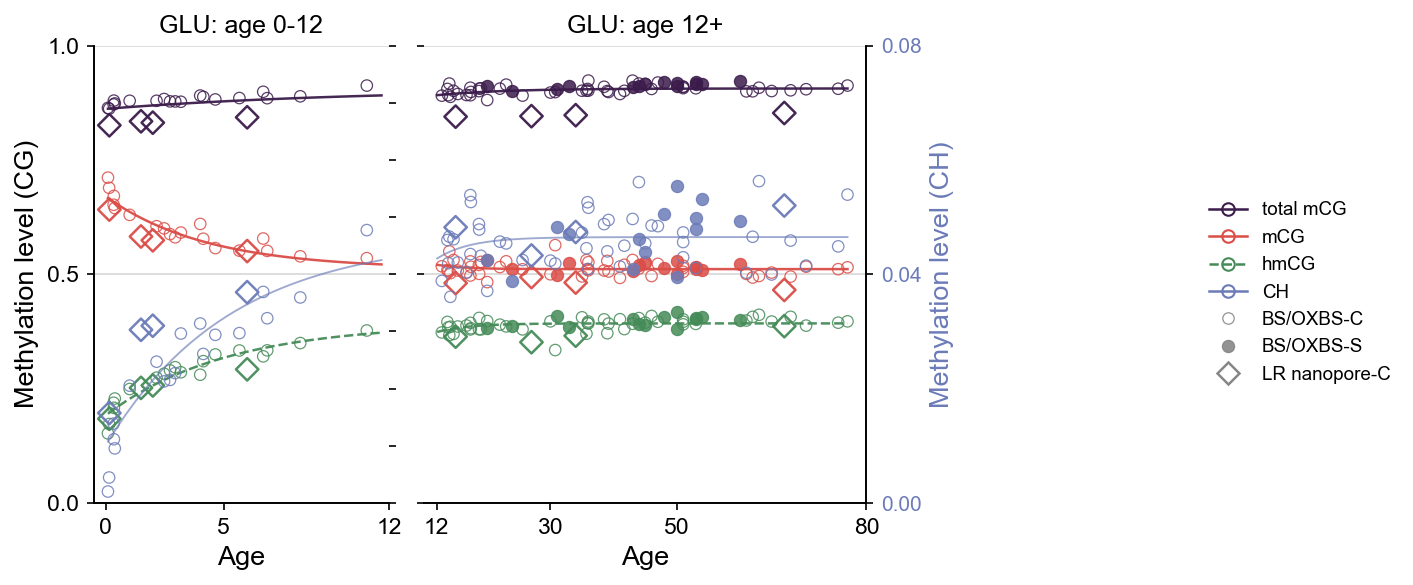

In [20]:
metric_labels = {'tmCG': 'total mCG', 'mCG': 'mCG', 'hmCG': 'hmCG', 'CH': 'CH'}
color_map = {'tmCG': '#3B1B4B', 'mCG': '#db4d47', 'hmCG': '#458B58', 'CH': '#6B7BB8'}
linestyle_map = {'tmCG': '-', 'mCG': '-', 'hmCG': '--', 'CH': '-'}
point_style_map = {
    ('BS/OXBS', 'C'): {'marker': 'o', 'facecolors': 'none', 's': 30, 'linewidth': .6, 'alpha': .85},
    ('BS/OXBS', 'S'): {'marker': 'o', 'facecolors': 'metric', 's': 34, 'linewidth': .6, 'alpha': .85},
    ('LR nanopore', 'C'): {'marker': 'D', 'facecolors': 'none', 's': 58, 'linewidth': 1.2, 'alpha': .95},
}

def exp_func(x, a, b, c):
    return a * np.exp(b * x) + c

def fit_exp_curve(df):
    values = df[['age', 'level']].dropna().astype(float)
    if len(values) < 4 or values.age.nunique() < 3:
        return None, None
    try:
        params, _ = curve_fit(exp_func, values.age, values.level,
                              p0=(.1, -.05, values.level.median()), maxfev=10000)
    except (RuntimeError, ValueError, TypeError):
        return None, None
    x_fit = np.linspace(values.age.min(), values.age.max(), 200)
    return x_fit, exp_func(x_fit, *params)

def point_handle(label, style):
    return Line2D([0], [0], marker=style['marker'], color='gray', linestyle='None',
                  markerfacecolor='gray' if style['facecolors'] == 'metric' else 'none',
                  markeredgecolor='gray', markeredgewidth=style['linewidth'], alpha=style['alpha'],
                  markersize=np.sqrt(style['s']), label=label)

for celltype in ['GABA', 'GLU']:
    df_ct = plot_df.query('celltype == @celltype').copy()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey=True, dpi=150,
                                   gridspec_kw={'width_ratios': [1, 1.5]})
    ax1_right, ax2_right = ax1.twinx(), ax2.twinx()

    # Match the latest nanopore presentation: CG metrics are shown as points;
    # CH is shown as its right-axis fitted trajectory.
    for source in ['BS/OXBS', 'LR nanopore']:
        for metric in ['tmCG', 'mCG', 'hmCG','CH']:
            for _, row in df_ct.query('source == @source and metric == @metric').sort_values('age').iterrows():
                style = point_style_map.get((row.source, row.SCZ))
                if style is None:
                    continue
                ax = (ax1 if metric != 'CH' else ax1_right) if row.age <= 12 else (ax2 if metric != 'CH' else ax2_right)
                facecolor = color_map[metric] if style['facecolors'] == 'metric' else style['facecolors']
                ax.scatter(row.age, row.level, marker=style['marker'], s=style['s'], facecolors=facecolor,
                           edgecolors=color_map[metric], linewidth=style['linewidth'], alpha=style['alpha'], zorder=3)

    for metric in ['tmCG', 'mCG', 'hmCG','CH']:
        x_fit, y_fit = fit_exp_curve(df_ct.query('metric == @metric'))
        if x_fit is None:
            continue
        for ax, mask in [(ax1 if metric != 'CH' else ax1_right, x_fit <= 12),
                         (ax2 if metric != 'CH' else ax2_right, x_fit >= 12)]:
            ax.plot(x_fit[mask], y_fit[mask], color=color_map[metric], linestyle=linestyle_map[metric],
                    linewidth=.9 if metric == 'CH' else 1.2, alpha=.65 if metric == 'CH' else .95, zorder=2)

    ax1.set_title(f'{celltype}: age 0-12', size=12); ax2.set_title(f'{celltype}: age 12+', size=12)
    ax1.set_xlabel('Age', size=13); ax2.set_xlabel('Age', size=13)
    ax1.set_xlim([-.5, 12]); ax2.set_xlim([10, 80])
    ax1.set_xticks([0, 5, 12]); ax2.set_xticks([12, 30, 50, 80])
    ax1.set_ylabel('Methylation level (CG)', size=13); ax1.set_ylim([0, 1]); ax2.set_yticks([0, .5, 1])
    for ax in [ax1, ax2]:
        ax.tick_params(axis='both', labelsize=11); ax.grid(axis='y', linestyle='-', alpha=.5)
    ax1_right.set_ylim([0, .08]); ax2_right.set_ylim([0, .08]); ax1_right.set_yticklabels([])
    ax2_right.set_yticks([0, .04, .08]); ax2_right.set_ylabel('Methylation level (CH)', color=color_map['CH'], size=13)
    ax1_right.tick_params(axis='y', labelcolor=color_map['CH']); ax2_right.tick_params(axis='y', labelcolor=color_map['CH'])
    ax1.spines['right'].set_visible(False); ax1.spines['top'].set_visible(False)
    ax2.spines['left'].set_visible(False); ax2.spines['top'].set_visible(False)
    for spine in ['top', 'right']:
        ax1_right.spines[spine].set_visible(False)
    for spine in ['top', 'left']:
        ax2_right.spines[spine].set_visible(False)

    handles = [Line2D([0], [0], marker='o', color=color_map[metric], linestyle=linestyle_map[metric],
                      linewidth=1.2, markerfacecolor='none', markeredgecolor=color_map[metric], markersize=6,
                      label=metric_labels[metric]) for metric in metric_labels]
    handles += [point_handle('BS/OXBS-C', point_style_map[('BS/OXBS', 'C')]),
                point_handle('BS/OXBS-S', point_style_map[('BS/OXBS', 'S')]),
                point_handle('LR nanopore-C', point_style_map[('LR nanopore', 'C')])]
    fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1, .5), frameon=False, fontsize=9)
    plt.tight_layout(rect=[0, 0, .82, 1])
    plt.show()
